In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time 

from phentax.waveform import IMRPhenomTHM

from lisaconstants import ASTRONOMICAL_YEAR

FIGSIZE = (10, 6)

## Phentax basic tutorial

#### First, create the waveform generator. 

Here we create all the allowed higher modes. The first step is initialize the waveform generator with the desired settings:

In [3]:
tlowfit = True # use a fit to set the starting time of the root finder used in t(f)
tol = 1e-12 # root finding tolerance
Tobs = 5 * ASTRONOMICAL_YEAR / 12

imr = IMRPhenomTHM(
        higher_modes="all",
        include_negative_modes=True, # negative m modes will be produced by simmetry
        t_low_fit=tlowfit,
        coarse_grain=False, # if false it will generate the waveform on a dense time grid with the specified timestep
        atol=tol,
        rtol=tol,
        T=Tobs,
    )

In [4]:
imr

IMRPhenomTHM(higher_modes=[21 33 44 55], include_negative_modes=True, coarse_grain=False, t_low=0.0, atol=1e-12, rtol=1e-12, T=13149229.068144)

#### generate amplitudes and phases for one single binary

Since we use `jax.jit` to speed up the waveform generation, we need to run it once to compile the code. 

Run the next two cells twice to verify the difference in performance.

In [5]:
m1 = 1e7
m2 = 5e6
chi1 = 0.9
chi2 = 0.3
distance = 500.0
inclination = jnp.pi / 3.0
phi_ref = 0.0
psi = 1.0 
f_min = 1e-4
delta_t = 10
f_ref = f_min
# t_ref = 0.0

to ensure compatibility with JAX's `vmap` functionality, every output has to have the same shape. 
For this reason, together with times and quantities of interest, we return a mask that for each binary indicates the valid time points.

In [6]:
wf_params, times, mask, amplitudes, phases = imr.compute_amp_phase(
        m1,
        m2,
        chi1,
        chi2,
        distance,
        phi_ref,
        inclination,
        psi,
        delta_t=delta_t,
        f_min=f_min,
        f_ref=f_ref,
    )

With `compute_amp_phase`, we can compute the amplitudes and phases of all the positive-m modes at once. Negative-m modes can be obtained from the positive-m modes by symmetry.

In [7]:
num_binaries, num_modes, num_times = amplitudes.shape
print(f"Number of binaries: {num_binaries}")
print(f"Number of modes: {num_modes}")
print(f"Number of time points: {num_times}")

Number of binaries: 1
Number of modes: 5
Number of time points: 1314923


We can access the entries of a specific mode by indexing the second dimension of the output arrays. For example, to access the $(l,m)$ mode, we can do:

In [8]:
mode = (2, 1)
mode_idx = imr.get_mode_index(mode)
print(f"Index of mode {mode}: {mode_idx}") # should be 1

amplitude_mode, phase_mode = amplitudes[:, mode_idx, :], phases[:, mode_idx, :]

Index of mode (2, 1): 1


The overall list of modes included in the waveform can be accessed via the `modes_list` property:

In [9]:
print(f"Modes included in the waveform: \n {imr.modes_list}")

Modes included in the waveform: 
 [[ 2  2]
 [ 2  1]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 2 -2]
 [ 2 -1]
 [ 3 -3]
 [ 4 -4]
 [ 5 -5]]


#### generate plus and cross polarizations for one single binary

In [10]:
times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
        m1,
        m2,
        chi1,
        chi2,
        distance,
        phi_ref,
        inclination,
        psi,
        delta_t=delta_t,
        f_min=f_min,
        f_ref=f_ref,
    )

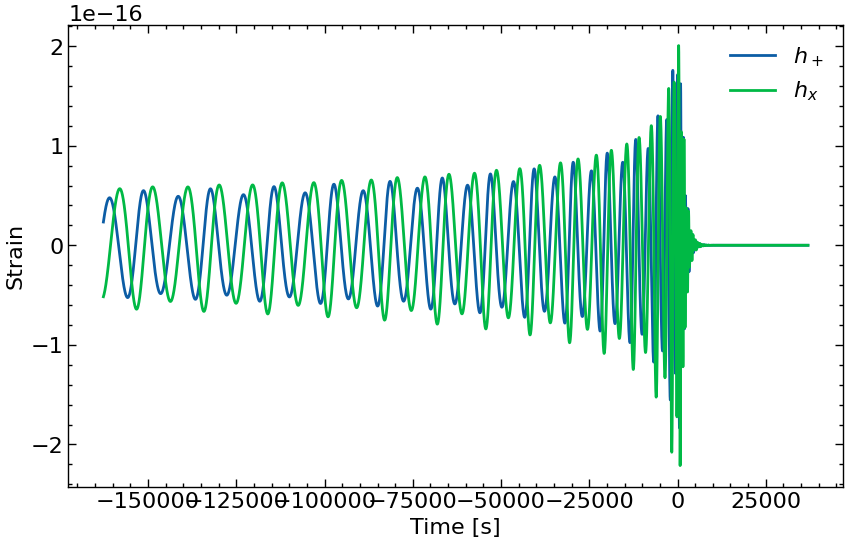

In [11]:
fig = plt.figure(figsize=FIGSIZE)
plt.plot(times[mask], h_plus[mask], label=r"$h_+$")
plt.plot(times[mask], h_cross[mask], label=r"$h_x$")
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.show()

In [12]:
# empty the memory allocated by jax
del times, mask, h_plus, h_cross

#### we can use the same logic and signature to generate a batch of waveforms. 

For simplicity, here we add a random deviation from the previous parameters.

In [13]:
key = jax.random.PRNGKey(0)

Since the input shape of our waveform's parameters is now (batch_size,), we have to recompile the waveform function.

Again, run the next two cells twice to verify the difference in performance.

In [14]:
num_binaries = 10
num_params = 8

key, subkey = jax.random.split(key)
random_params = jax.random.uniform(subkey, (num_binaries, num_params))

m1_batch = ( 1 + 0.7 * random_params[:, 0]) * m1
m2_batch = ( 1 + 0.5 * random_params[:, 1]) * m2
chi1_batch = (1 + 0.1 * random_params[:, 2]) * chi1
chi2_batch =  (1 + 0.1 * random_params[:, 3]) * chi2
distance_batch = (1 + 0.1 * random_params[:, 4]) * distance
phi_ref_batch = ( 1 + 0.1 * random_params[:, 5]) * phi_ref
psi_batch = ( 1 + 0.1 * random_params[:, 6]) * psi
inclination_batch = (1 + 0.1 * random_params[:, 7]) * inclination

In [15]:
tic = time.time()

times_batch, mask_batch, h_plus_batch, h_cross_batch = imr.compute_polarizations_at_once(
        m1_batch,
        m2_batch,
        chi1_batch,
        chi2_batch,
        distance_batch,
        phi_ref_batch,
        inclination_batch,
        psi_batch,
        delta_t=delta_t,
        f_min=f_min,
        f_ref=f_ref,
        T = 3 / 12 * ASTRONOMICAL_YEAR
    )

h_plus_batch.block_until_ready()
print(f"Time elapsed: {time.time() - tic} s")

Time elapsed: 11.360782146453857 s


The compilation is needed only when the shape of the input arrays changes. 

The dimension along the time axis of the waveform is given by the observation time `T`.

This allows to avoid the need of recompiling the internal functions when the required duration changes with the mass.

In [16]:
h_plus_batch.shape

(10, 788954)

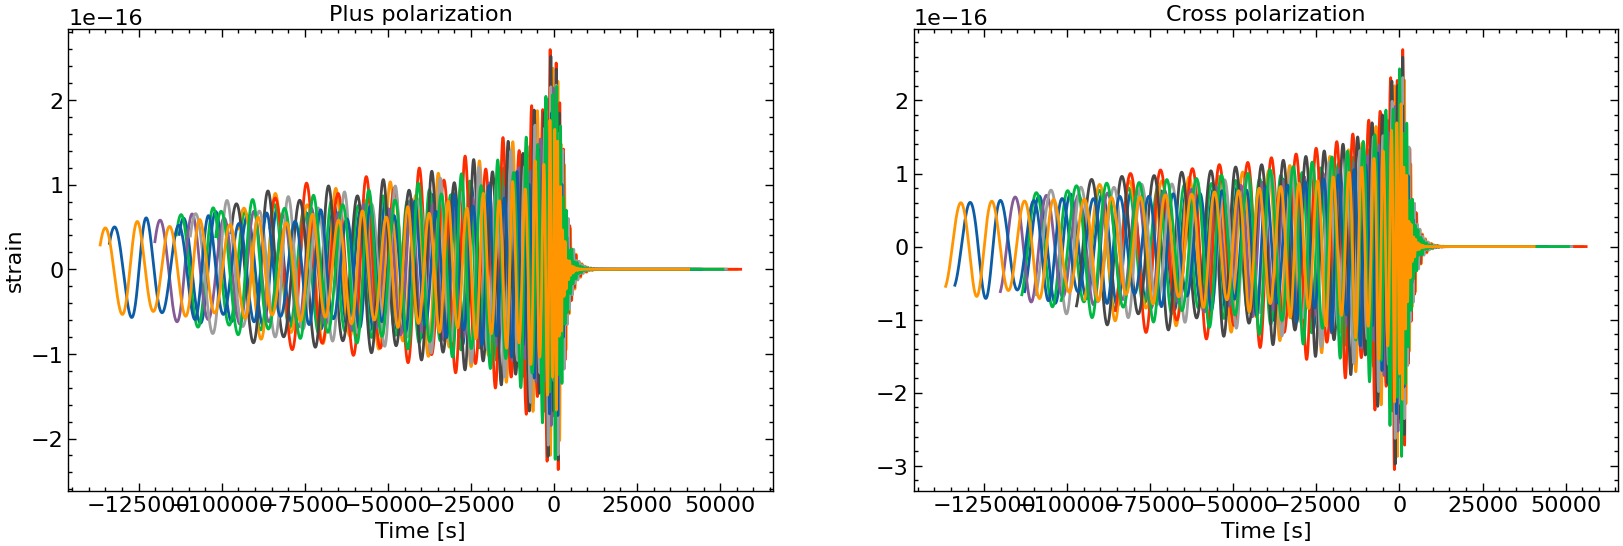

In [17]:
# plot all the polarizations
fig, axs = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))
for i in range(10):
    axs[0].plot(times_batch[i][mask_batch[i]], h_plus_batch[i][mask_batch[i]])
    axs[1].plot(times_batch[i][mask_batch[i]], h_cross_batch[i][mask_batch[i]])

axs[0].set_title("Plus polarization")
axs[1].set_title("Cross polarization")
#plt.legend()
axs[0].set_xlabel("Time [s]")
axs[1].set_xlabel("Time [s]")
axs[0].set_ylabel("strain")
plt.show()

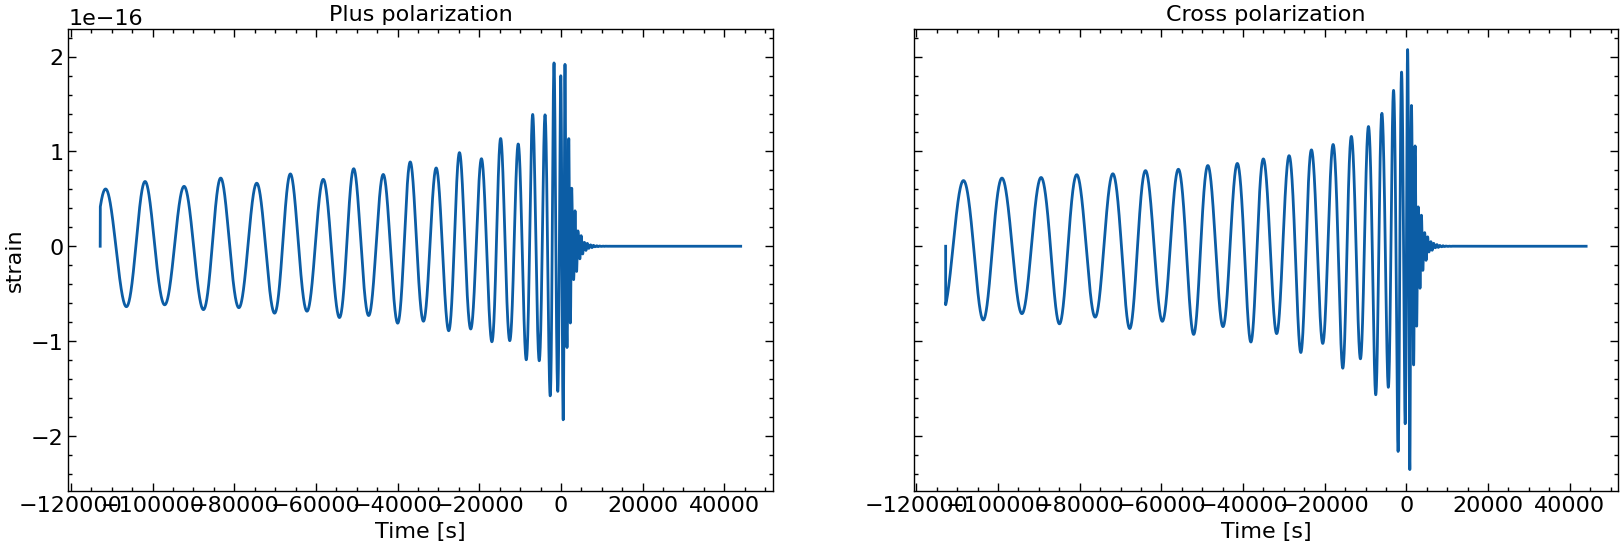

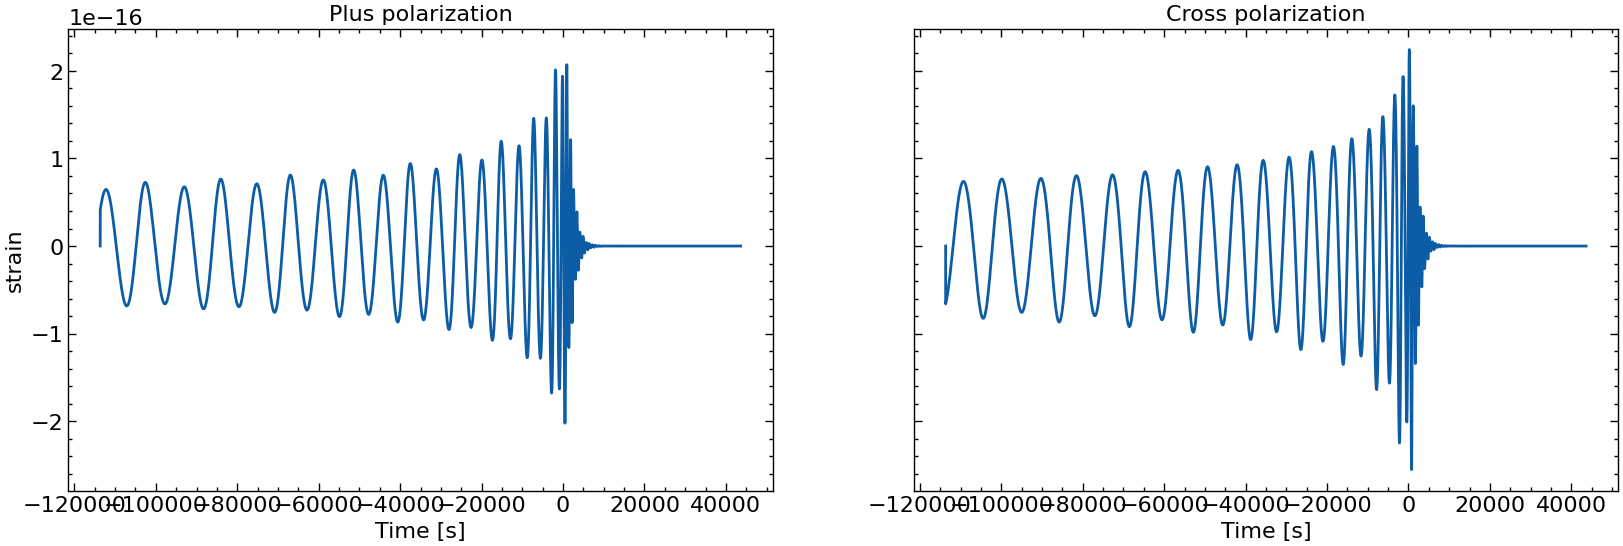

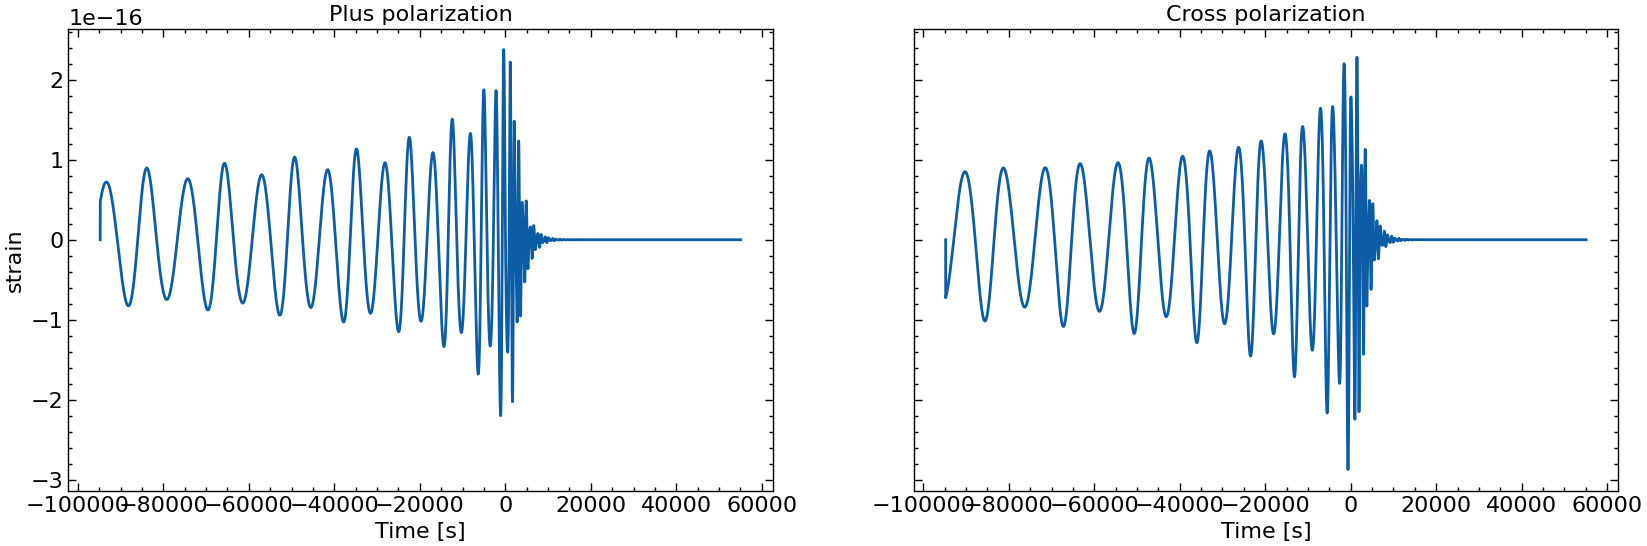

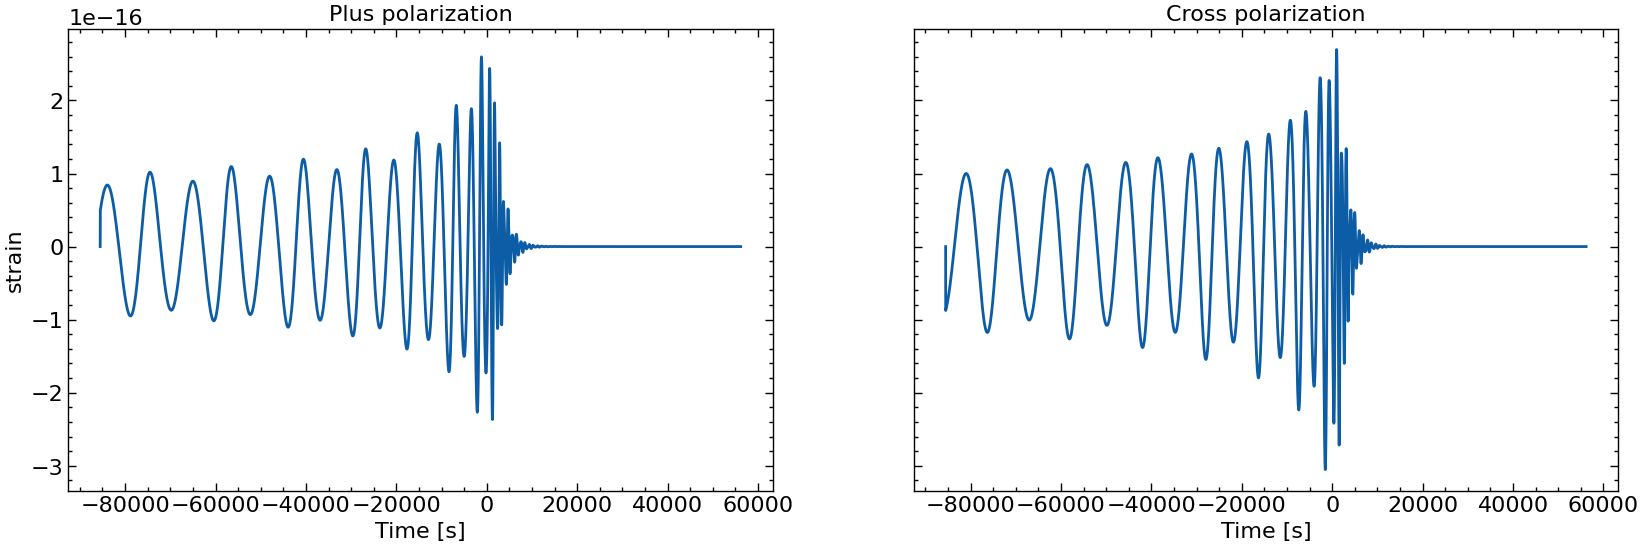

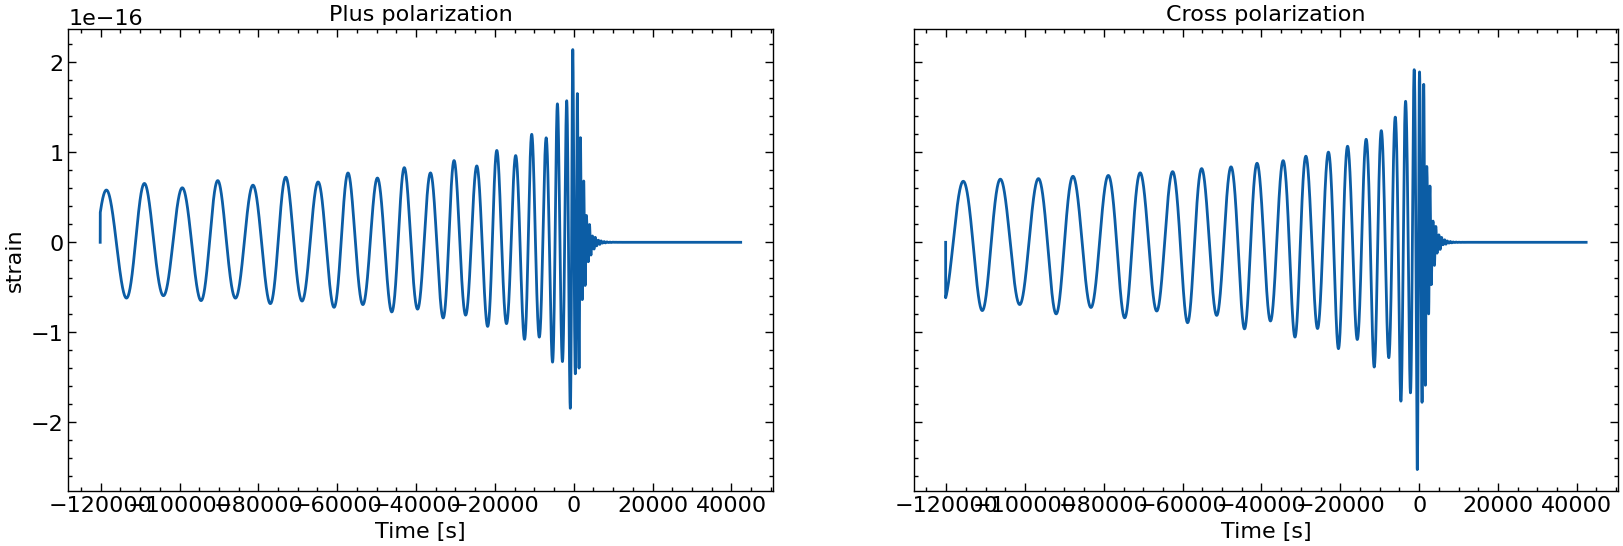

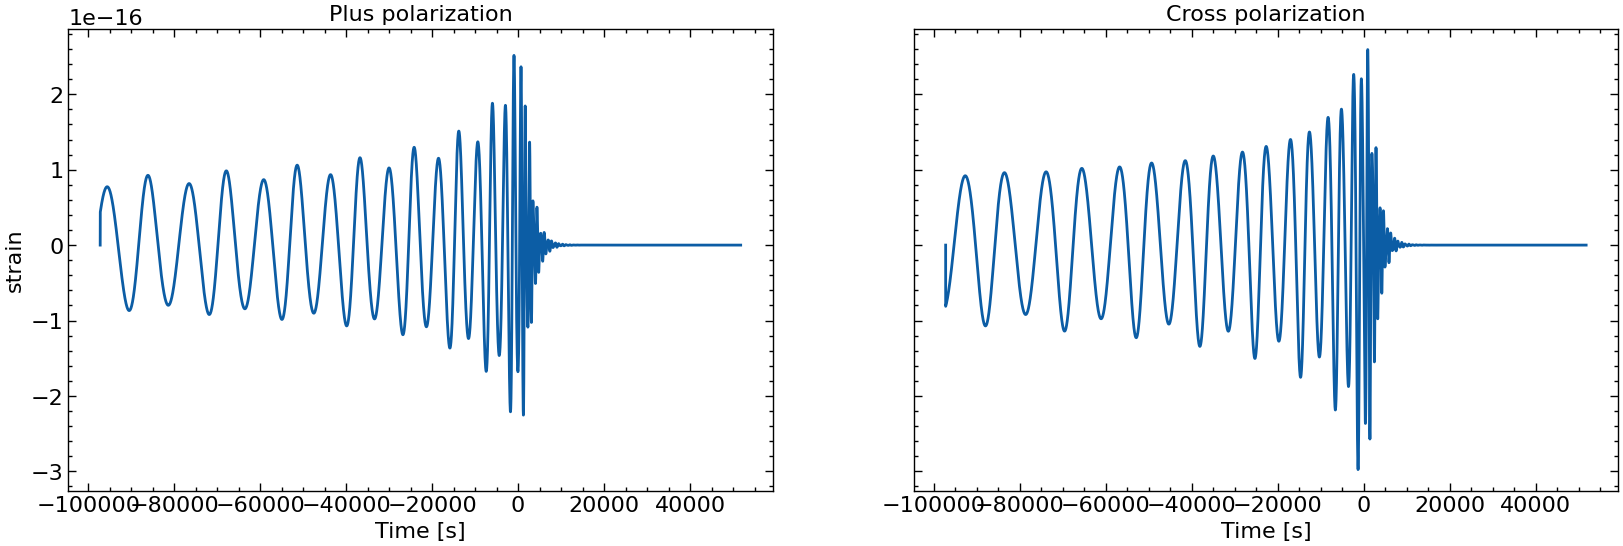

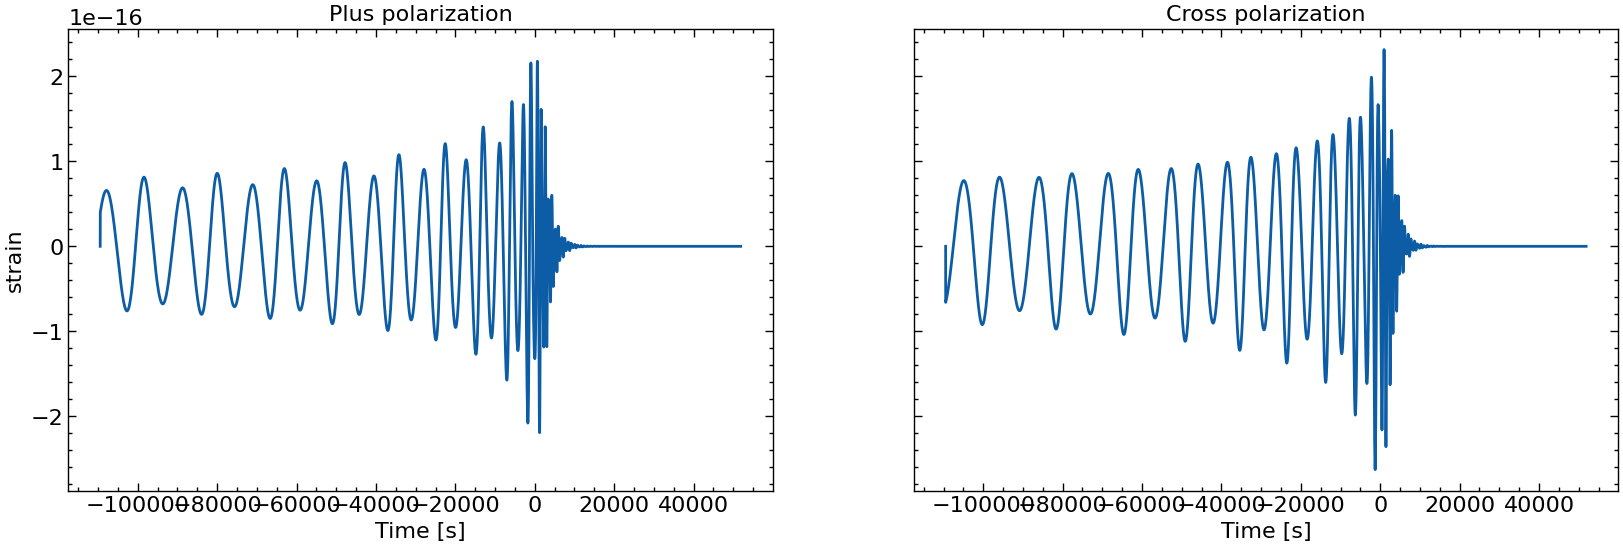

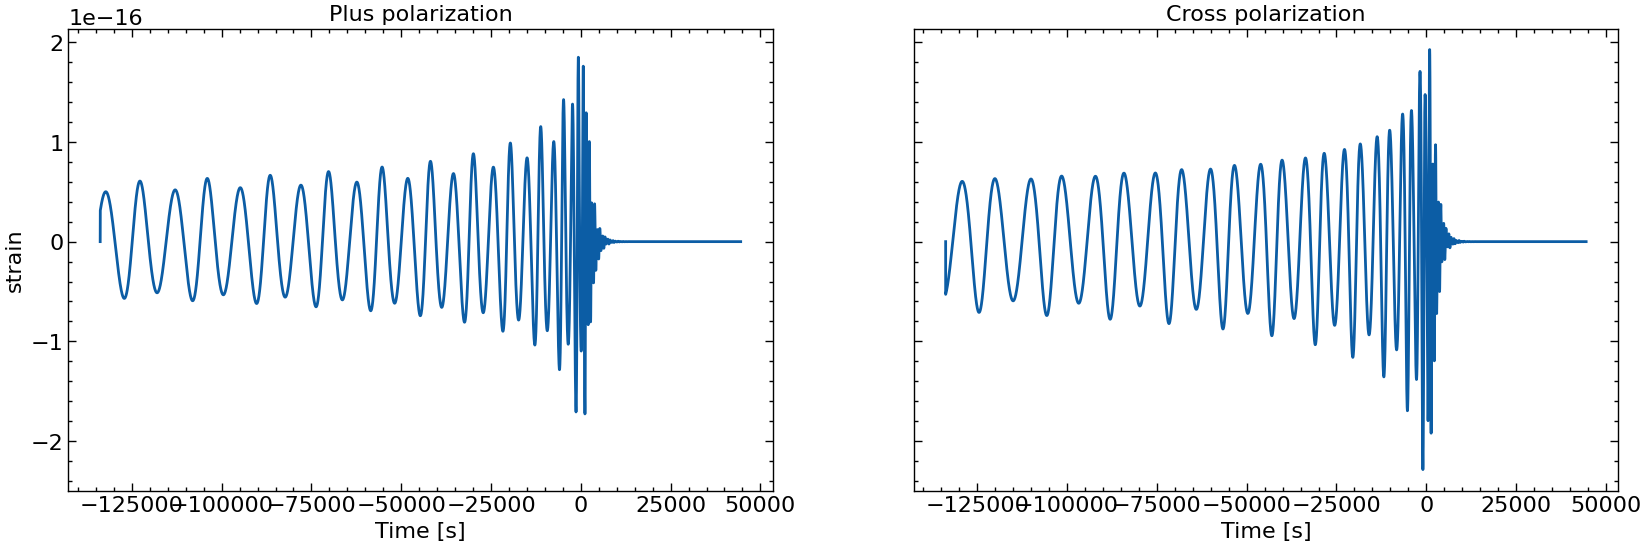

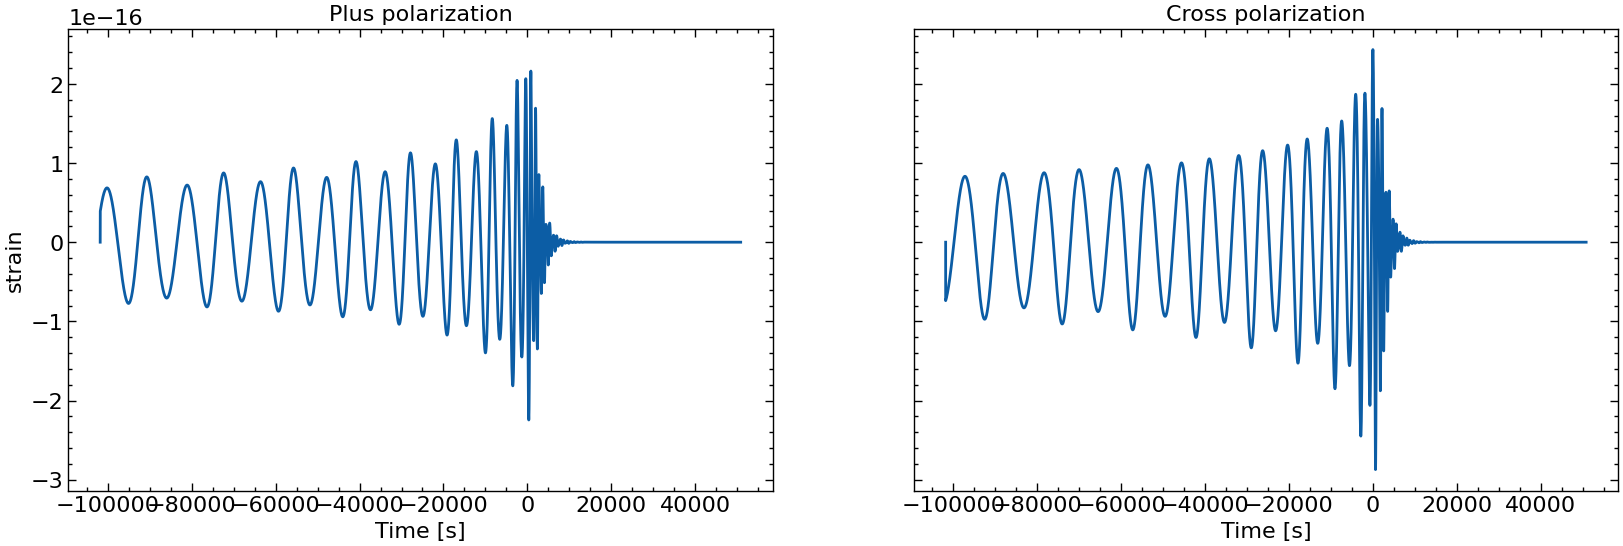

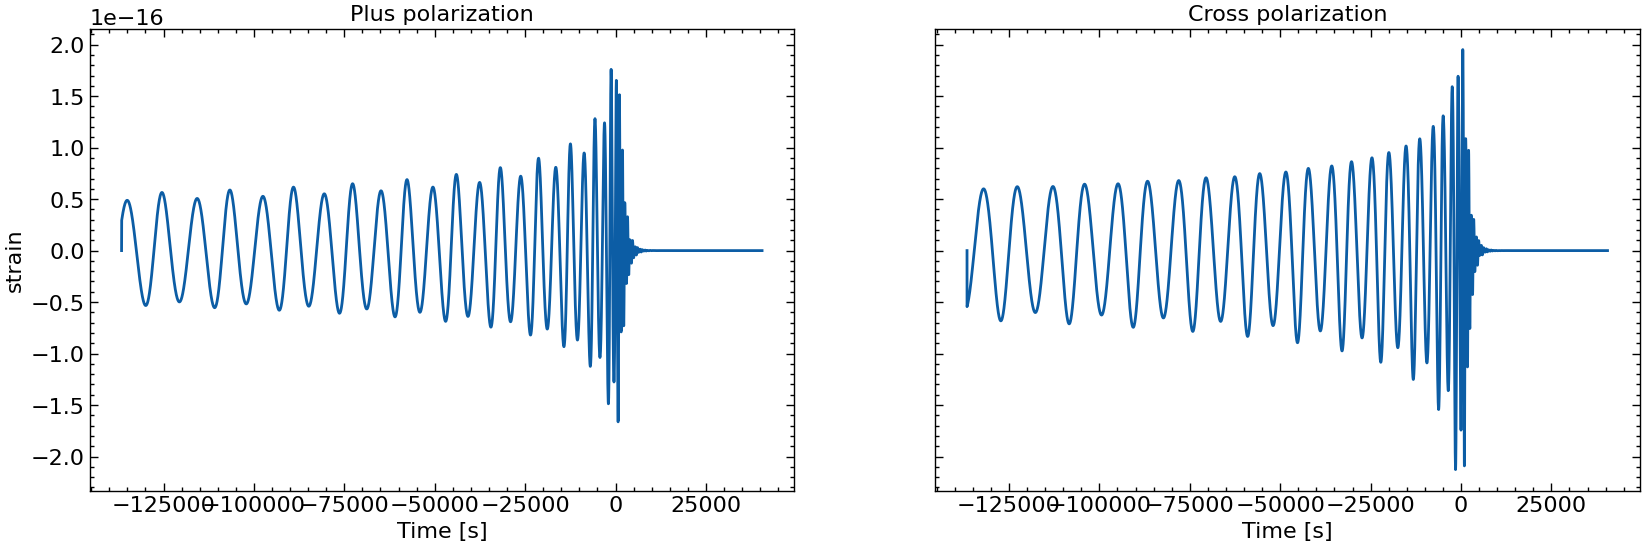

In [18]:
# also plot them individually
for i in range(10):
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))
    axs[0].plot(times_batch[i], h_plus_batch[i])
    axs[1].plot(times_batch[i], h_cross_batch[i])

    axs[0].set_title("Plus polarization")
    axs[1].set_title("Cross polarization")
    #plt.legend()
    axs[0].set_xlabel("Time [s]")
    axs[1].set_xlabel("Time [s]")
    axs[0].set_ylabel("strain")
    plt.show()

#### Check against PhenomXPY

In [19]:
from phenomxpy.phenomt.internals import pWF
from phenomxpy.phenomt.phenomt import IMRPhenomTHM as xpy_thm

In [20]:
batch_idx = 3

m1_here = float(m1_batch[batch_idx])
m2_here = float(m2_batch[batch_idx])
chi1_here = float(chi1_batch[batch_idx])
chi2_here = float(chi2_batch[batch_idx])
distance = float(distance_batch[batch_idx])
inclination_here = float(inclination_batch[batch_idx])
psi_here = float(psi_batch[batch_idx])
phi_ref_here = float(phi_ref_batch[batch_idx])

In [21]:
tic = time.time()
pwf = pWF(
        eta=m1_here * m2_here / (m1_here + m2_here) ** 2,
        s1=chi1_here,
        s2=chi2_here,
        f_min=f_min,
        f_ref=f_ref,
        total_mass=m1_here + m2_here,
        distance=distance,
        inclination=inclination_here,
        polarization_angle=psi_here,
        delta_t=delta_t,
        phi_ref=phi_ref_here,
    )

mode_array = None

xpy_wave_gen = xpy_thm(mode_array=mode_array, pWF_input=pwf)

xpy_plus, xpy_cross, xpy_times = xpy_wave_gen.compute_polarizations()

print(f"Time elapsed: {time.time() - tic} s")


Time elapsed: 5.61545205116272 s


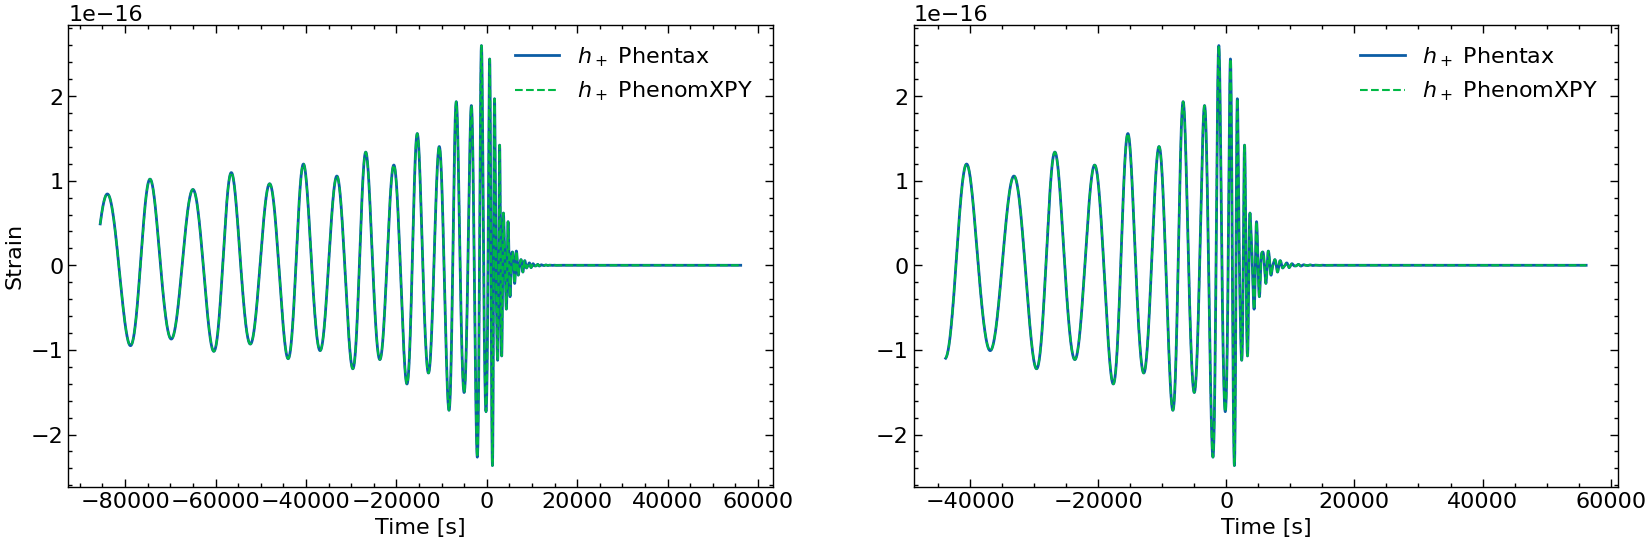

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))
axs[0].plot(times_batch[batch_idx][mask_batch[batch_idx]], h_plus_batch[batch_idx][mask_batch[batch_idx]], label=r'$h_+$ Phentax')
axs[0].plot(xpy_times, xpy_plus, lw=1.5, ls='--', label=r'$h_+$ PhenomXPY')
axs[0].legend()
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Strain')

# zoom on the end 
axs[1].plot(times_batch[batch_idx][-10000:], h_plus_batch[batch_idx][-10000:], label=r'$h_+$ Phentax')
axs[1].plot(xpy_times[-10000:], xpy_plus[-10000:], lw=1.5, ls='--', label=r'$h_+$ PhenomXPY')
axs[1].legend()
axs[1].set_xlabel('Time [s]')

plt.show()

### spline phenomxpy to compute the difference

Since the two code may return different time grids, we need to compare on the same one.

In [23]:
from scipy.interpolate import Akima1DInterpolator 

In [24]:
times_here = times_batch[batch_idx][mask_batch[batch_idx]][:-1] # remove the very last point for the interpolation. it's zero anyways

spline = Akima1DInterpolator(xpy_times, xpy_plus)
xpy_new_times = spline(times_here)

In [25]:
np.isclose(h_plus_batch[batch_idx][mask_batch[batch_idx]][:-1], xpy_new_times).all()

np.True_

### ~$\mathcal{Fin}$